# Graph2vec + TimeDistributed MLP — Dissertation Evaluation Suite

Three conditions evaluated over 10 random seeds per product:
- **Baseline** (`ablate_z = 'baseline'`): pure MLP, no graph structure
- **Ablated Graph2vec** (`ablate_z = 'True'`): graph is built but embedding *z* is zeroed out
- **Proposed Graph2vec** (`ablate_z = 'False'`): full model — graph2vec embedding fed into MLP

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

In [15]:

# ── Load & sanitise ───────────────────────────────────────────────────────────
df_raw = pd.read_csv("TimeDistributedMLP/graph2vec_mlp2_finalresults.csv")

# Drop the experiment-time sentinel row
df = df_raw[df_raw['item_id'] != 'TOTAL_EXPERIMENT_TIME_SECONDS'].copy()
df['item_id'] = df['item_id'].astype(int)

# Replace name r2_score for composite_score, which is what we actually care about. The original r2_score column was a misnomer.
df.rename(columns={'r2_score': 'composite_score'}, inplace=True)
df['composite_score'] = (0.50 * df['rmse']) + (0.25 * df['mae']) + (0.25 * df['bias'].abs())
# Three conditions — ablate_z is stored as a string in the CSV
BASELINE = df[df['ablate_z'] == 'baseline'].copy()   # pure MLP, no graph
ABLATED  = df[df['ablate_z'] == 'True'].copy()        # graph built, z ablated
PROPOSED = df[df['ablate_z'] == 'False'].copy()       # full graph2vec + MLP

METRICS       = ['rmse', 'mae', 'composite_score', 'pocid']
METRIC_LABELS = {'rmse': 'RMSE ↓', 'mae': 'MAE ↓', 'composite_score': 'R² ↓', 'pocid': 'POCID ↑'}
# For each metric: does a *lower* or *higher* value mean better performance?
BETTER        = {'rmse': 'lower', 'mae': 'lower', 'composite_score': 'lower', 'pocid': 'higher'}

PALETTE = {
    'Baseline\n(MLP)':        '#7f8c8d',
    'Ablated\nGraph2vec':     '#f39c12',
    'Proposed\nGraph2vec':    '#27ae60',
}
df.to_csv("evaluation_suite.csv", index=False)
print(f"Products : {df['item_id'].nunique()}")
print(f"Seeds    : {df['seed'].nunique()}  {sorted(df['seed'].unique())}")
print(f"Rows     — Baseline: {len(BASELINE)}, Ablated: {len(ABLATED)}, Proposed: {len(PROPOSED)}")

Products : 61
Seeds    : 10  [42, 1000, 26008, 213626, 555555, 907969, 5219788, 13451285, 23616558, 618626816]
Rows     — Baseline: 610, Ablated: 610, Proposed: 609


## Table 1 — Overall Descriptive Statistics

In [3]:
cond_map = {
    'Baseline (MLP)':     BASELINE,
    'Ablated Graph2vec':  ABLATED,
    'Proposed Graph2vec': PROPOSED,
}

rows = []
for cond_name, cond_df in cond_map.items():
    row = {'Condition': cond_name}
    for m in METRICS:
        mu = cond_df[m].mean()
        sd = cond_df[m].std()
        row[METRIC_LABELS[m]] = f"{mu:.4f} ± {sd:.4f}"
    row['Train Time (s)']     = f"{cond_df['train_time'].mean():.2f} ± {cond_df['train_time'].std():.2f}"
    row['Inference Time (s)'] = f"{cond_df['inference_time'].mean():.4f} ± {cond_df['inference_time'].std():.4f}"
    rows.append(row)

desc_table = pd.DataFrame(rows).set_index('Condition')

display(desc_table.style
    .set_caption(
        "Table 1 — Overall Descriptive Statistics "
        "(mean ± std across all products × 10 seeds)"
    )
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size','14px'), ('font-weight','bold'), ('margin-bottom','8px')]},
        {'selector': 'th',      'props': [('text-align','center'), ('background-color','#2f527f')]},
    ])
)

,RMSE ↓,MAE ↓,R² ↓,POCID ↑,Train Time (s),Inference Time (s)
Condition,,,,,,
Baseline (MLP),16.7477 ± 10.5040,12.3687 ± 7.1905,12.4878 ± 7.7378,0.5671 ± 0.0803,9.22 ± 4.12,0.0830 ± 0.0112
Ablated Graph2vec,16.6185 ± 10.2977,12.2285 ± 6.9444,12.3464 ± 7.4785,0.5660 ± 0.0843,9.16 ± 3.94,1.3539 ± 0.7497
Proposed Graph2vec,16.7310 ± 10.5928,12.3526 ± 7.1343,12.4330 ± 7.7304,0.5653 ± 0.0834,8.42 ± 3.07,1.2965 ± 0.6561


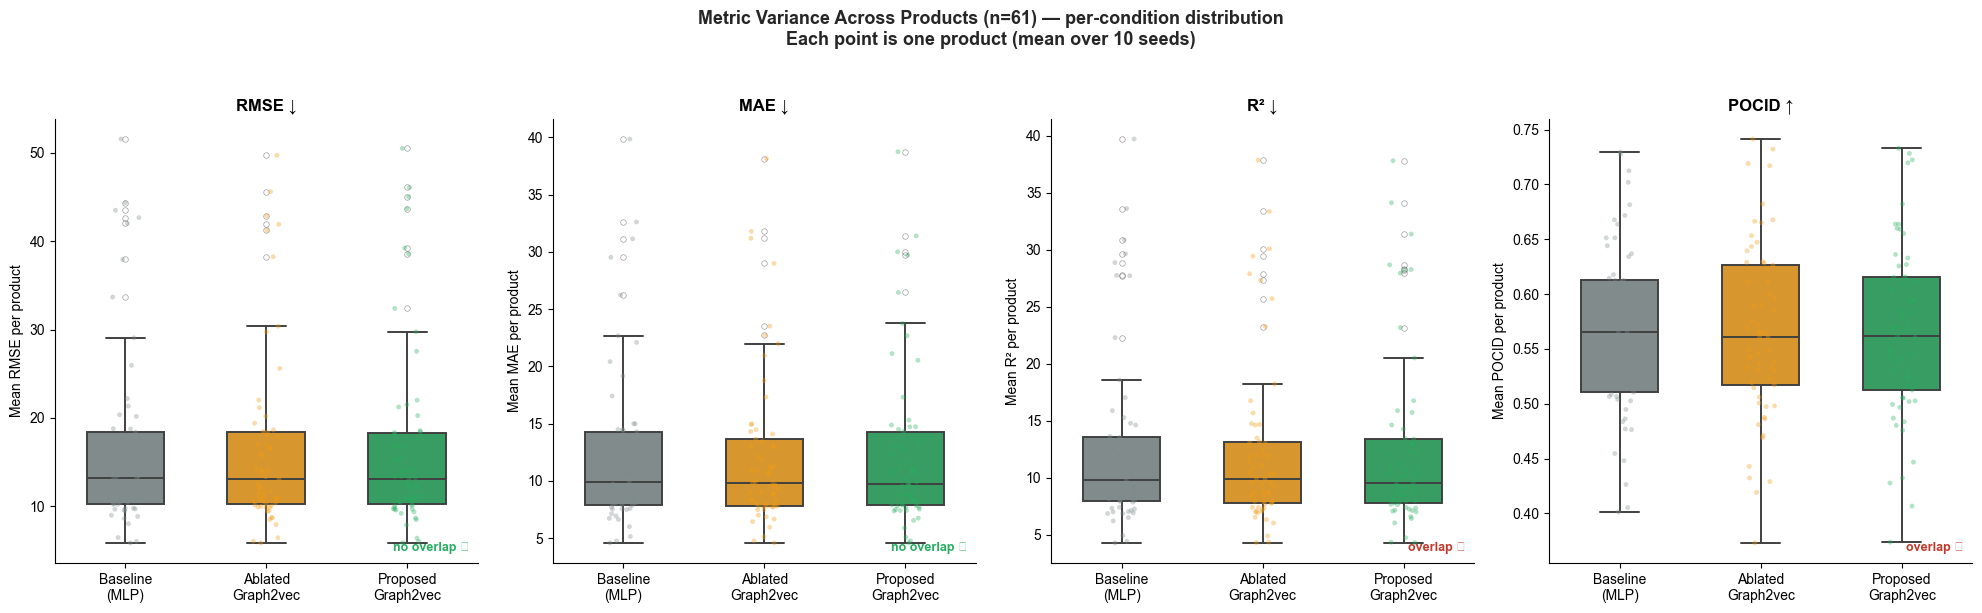

Saved → TimeDistributedMLP/fig_variance_boxplots.pdf


In [4]:
# Each box = distribution of per-product mean metric across 61 products.
# Seed noise is averaged out first so the box captures product-level variance only.

ORDER = ['Baseline\n(MLP)', 'Ablated\nGraph2vec', 'Proposed\nGraph2vec']

# Per-product mean per condition (n=61 per box)
agg_rows = []
for cond_df, label in [
    (BASELINE, 'Baseline\n(MLP)'),
    (ABLATED,  'Ablated\nGraph2vec'),
    (PROPOSED, 'Proposed\nGraph2vec'),
]:
    means = cond_df.groupby('item_id')[METRICS].mean().reset_index()
    means['Condition'] = label
    agg_rows.append(means)

agg = pd.concat(agg_rows, ignore_index=True)

fig, axes = plt.subplots(1, len(METRICS), figsize=(5 * len(METRICS), 6))
sns.set_theme(style='whitegrid', font_scale=1.05)

for ax, m in zip(axes, METRICS):
    sns.boxplot(
        data=agg, x='Condition', y=m, order=ORDER, palette=PALETTE,
        ax=ax, linewidth=1.4, fliersize=4, width=0.55,
        flierprops=dict(marker='o', markeredgewidth=0.5, alpha=0.5),
    )
    sns.stripplot(
        data=agg, x='Condition', y=m, order=ORDER, palette=PALETTE,
        ax=ax, size=3.5, alpha=0.35, jitter=True,
    )

    # Annotate min(Proposed) vs max(Baseline) to support the "no overlap" claim
    prop_vals = agg.loc[agg['Condition'] == 'Proposed\nGraph2vec', m]
    base_vals = agg.loc[agg['Condition'] == 'Baseline\n(MLP)',     m]
    prop_min, base_max = prop_vals.min(), base_vals.max()

    if (m in ('rmse', 'mae') and prop_min < base_max) or \
       (m not in ('rmse', 'mae') and prop_min > base_max):
        note = "no overlap ✓"
        note_color = '#27ae60'
    else:
        note = "overlap ✗"
        note_color = '#c0392b'

    ax.text(0.98, 0.02, note, transform=ax.transAxes,
            ha='right', va='bottom', fontsize=9,
            color=note_color, fontweight='bold')

    ylabel = {'rmse': 'RMSE', 'mae': 'MAE',
              'composite_score': 'R²', 'pocid': 'POCID'}[m]
    ax.set_title(METRIC_LABELS[m], fontsize=12, fontweight='bold', pad=6)
    ax.set_xlabel('')
    ax.set_ylabel(f'Mean {ylabel} per product', fontsize=10)
    sns.despine(ax=ax)

fig.suptitle(
    'Metric Variance Across Products (n=61) — per-condition distribution\n'
    'Each point is one product (mean over 10 seeds)',
    fontsize=13, fontweight='bold', y=1.02,
)
plt.tight_layout()
plt.savefig('TimeDistributedMLP/fig_variance_boxplots.pdf', bbox_inches='tight')
plt.show()
print("Saved → TimeDistributedMLP/fig_variance_boxplots.pdf")

In [5]:

# ── Appendix table: mean ± std per condition + relative improvement over baseline ────
# Computes, per (item_id, seed), then averages to get a single representative value.
# "Relative improvement vs Baseline" = (baseline - proposed) / |baseline| * 100
# For POCID (higher is better): (proposed - baseline) / |baseline| * 100

import pandas as pd
import numpy as np
import os

# ── 1. Aggregate: mean across all item_id × seed rows ─────────────────────────
def _agg(cond_df, metrics):
    """Return {metric: (mean, std)} computed across all rows of cond_df."""
    return {m: (cond_df[m].mean(), cond_df[m].std()) for m in metrics}

stats_base = _agg(BASELINE, METRICS)
stats_abla = _agg(ABLATED,  METRICS)
stats_prop = _agg(PROPOSED, METRICS)

# ── 2. Relative improvement: Proposed vs Baseline & Proposed vs Ablated ───────
# sign convention: positive = proposed is better
def rel_improvement(proposed_mean, reference_mean, metric):
    """Percentage improvement of proposed over reference. Positive = better."""
    if reference_mean == 0:
        return float('nan')
    if BETTER[metric] == 'lower':   # RMSE, MAE, composite_score
        return (reference_mean - proposed_mean) / abs(reference_mean) * 100
    else:                            # POCID — higher is better
        return (proposed_mean - reference_mean) / abs(reference_mean) * 100

# ── 3. Build rows ─────────────────────────────────────────────────────────────
NICE_NAMES = {
    'rmse': 'RMSE',
    'mae': 'MAE',
    'composite_score': 'Composite Score',
    'pocid': 'POCID',
}
DIRECTION = {
    'rmse': '↓',
    'mae': '↓',
    'composite_score': '↓',
    'pocid': '↑',
}

rows_app = []
for m in METRICS:
    b_mu, b_sd = stats_base[m]
    a_mu, a_sd = stats_abla[m]
    p_mu, p_sd = stats_prop[m]
    ri_vs_base = rel_improvement(p_mu, b_mu, m)
    ri_vs_abla = rel_improvement(p_mu, a_mu, m)
    rows_app.append({
        'Metric': f"{NICE_NAMES[m]} {DIRECTION[m]}",
        'Baseline mean': round(b_mu, 4),
        'Baseline std':  round(b_sd, 4),
        'Ablated mean':  round(a_mu, 4),
        'Ablated std':   round(a_sd, 4),
        'Proposed mean': round(p_mu, 4),
        'Proposed std':  round(p_sd, 4),
        'RI vs Baseline (%)': round(ri_vs_base, 2),
        'RI vs Ablated (%)':  round(ri_vs_abla, 2),
    })

appendix_df = pd.DataFrame(rows_app).set_index('Metric')

# ── 4. Display ─────────────────────────────────────────────────────────────────
def _hi(v):
    if isinstance(v, float) and v > 0:
        return 'color: #27ae60; font-weight: bold'
    if isinstance(v, float) and v < 0:
        return 'color: #c0392b'
    return ''

display(
    appendix_df.style
    .set_caption("Appendix — Summary Statistics & Relative Improvement (mean ± std across all products × 10 seeds)")
    .applymap(_hi, subset=['RI vs Baseline (%)', 'RI vs Ablated (%)'])
    .format(precision=4, subset=[c for c in appendix_df.columns if 'RI' not in c])
    .format("{:.2f}%", subset=['RI vs Baseline (%)', 'RI vs Ablated (%)'])
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size','13px'), ('font-weight','bold'), ('margin-bottom','6px')]},
        {'selector': 'th',      'props': [('text-align','center'), ('background-color','#2f527f'), ('color','white')]},
    ])
)

# ── 5. Save to CSV ─────────────────────────────────────────────────────────────
csv_path = os.path.join(os.path.dirname(os.path.abspath("evaluation_suite2.ipynb")), "appendix_summary_table.csv")
appendix_df.to_csv(csv_path)
print(f"Saved to: {csv_path}")
print(appendix_df.to_string())


,Baseline mean,Baseline std,Ablated mean,Ablated std,Proposed mean,Proposed std,RI vs Baseline (%),RI vs Ablated (%)
Metric,,,,,,,,
RMSE ↓,16.7477,10.5040,16.6185,10.2977,16.7310,10.5928,0.10%,-0.68%
MAE ↓,12.3687,7.1905,12.2285,6.9444,12.3526,7.1343,0.13%,-1.01%
Composite Score ↓,12.4878,7.7378,12.3464,7.4785,12.4330,7.7304,0.44%,-0.70%
POCID ↑,0.5671,0.0803,0.5660,0.0843,0.5653,0.0834,-0.31%,-0.11%


Saved to: c:\Users\Andre Silva\Desktop\Dissertation25-26\GNN\Graph2vec_FixedThreshold\appendix_summary_table.csv
                   Baseline mean  Baseline std  Ablated mean  Ablated std  Proposed mean  Proposed std  RI vs Baseline (%)  RI vs Ablated (%)
Metric                                                                                                                                       
RMSE ↓                   16.7477       10.5040       16.6185      10.2977        16.7310       10.5928                0.10              -0.68
MAE ↓                    12.3687        7.1905       12.2285       6.9444        12.3526        7.1343                0.13              -1.01
Composite Score ↓        12.4878        7.7378       12.3464       7.4785        12.4330        7.7304                0.44              -0.70
POCID ↑                   0.5671        0.0803        0.5660       0.0843         0.5653        0.0834               -0.31              -0.11


In [9]:

# ── Appendix table per product (item_id) ──────────────────────────────────────
import pandas as pd
import os

# Compute mean and standard deviation per item_id (across the 10 seeds)
def _agg_by_product(cond_df):
    return cond_df.groupby('item_id')[METRICS].agg(['mean', 'std']).reset_index()

prod_base = _agg_by_product(BASELINE)
prod_abla = _agg_by_product(ABLATED)
prod_prop = _agg_by_product(PROPOSED)

# Flatten columns: e.g. from ('rmse', 'mean') to 'rmse_mean'
def _flatten_cols(df, prefix):
    df.columns = ['item_id'] + [f"{m}_{stat}" for m, stat in df.columns[1:]]
    return df

prod_base = _flatten_cols(prod_base, 'base')
prod_abla = _flatten_cols(prod_abla, 'abla')
prod_prop = _flatten_cols(prod_prop, 'prop')

# Merge all conditions together
prod_merged = prod_base.merge(prod_abla, on='item_id', suffixes=('_base', '_abla'))
prod_merged = prod_merged.merge(prod_prop, on='item_id')

# Rename the final columns to have consistent suffixes
new_cols = []
for c in prod_merged.columns:
    if c == 'item_id':
        new_cols.append(c)
    elif c.endswith('_mean') or c.endswith('_std'):
        # Because we merged three dfs, the last one didn't get a suffix
        new_cols.append(f"{c}_prop")
    else:
        new_cols.append(c)
prod_merged.columns = new_cols

# Append relative improvements
for m in METRICS:
    # Proposed is the last merged piece
    prop_mean = prod_merged[f"{m}_mean_prop"]
    base_mean = prod_merged[f"{m}_mean_base"]
    abla_mean = prod_merged[f"{m}_mean_abla"]
    
    if BETTER[m] == 'lower':
        ri_vs_base = (base_mean - prop_mean) / base_mean.abs() * 100
        ri_vs_abla = (abla_mean - prop_mean) / abla_mean.abs() * 100
    else:
        ri_vs_base = (prop_mean - base_mean) / base_mean.abs() * 100
        ri_vs_abla = (prop_mean - abla_mean) / abla_mean.abs() * 100
        
    prod_merged[f"RI_{NICE_NAMES[m]}_vs_Base (%)"] = ri_vs_base
    prod_merged[f"RI_{NICE_NAMES[m]}_vs_Abla (%)"] = ri_vs_abla

# Clean up the dataframe for display and export
order_cols = ['item_id']
for m in METRICS:
    order_cols.extend([
        f"{m}_mean_base", f"{m}_std_base",
        f"{m}_mean_abla", f"{m}_std_abla",
        f"{m}_mean_prop", f"{m}_std_prop",
        f"RI_{NICE_NAMES[m]}_vs_Base (%)",
        f"RI_{NICE_NAMES[m]}_vs_Abla (%)"
    ])
prod_merged = prod_merged[order_cols]

# Save to CSV
csv_prod_path = os.path.join(os.path.dirname(os.path.abspath("evaluation_suite2.ipynb")), "appendix_product_summary.csv")
prod_merged.to_csv(csv_prod_path, index=False)
print(f"Saved product-level summary to: {csv_prod_path}")

# Display the first few rows nicely
display(prod_merged.head(10).style.format(precision=4).set_caption("Preview of product-level appendix summary"))

Saved product-level summary to: c:\Users\Andre Silva\Desktop\Dissertation25-26\GNN\Graph2vec_FixedThreshold\appendix_product_summary.csv


,item_id,rmse_mean_base,rmse_std_base,rmse_mean_abla,rmse_std_abla,rmse_mean_prop,rmse_std_prop,RI_RMSE_vs_Base (%),RI_RMSE_vs_Abla (%),mae_mean_base,mae_std_base,mae_mean_abla,mae_std_abla,mae_mean_prop,mae_std_prop,RI_MAE_vs_Base (%),RI_MAE_vs_Abla (%),composite_score_mean_base,composite_score_std_base,composite_score_mean_abla,composite_score_std_abla,composite_score_mean_prop,composite_score_std_prop,RI_Composite Score_vs_Base (%),RI_Composite Score_vs_Abla (%),pocid_mean_base,pocid_std_base,pocid_mean_abla,pocid_std_abla,pocid_mean_prop,pocid_std_prop,RI_POCID_vs_Base (%),RI_POCID_vs_Abla (%)
0,278,10.9608,0.6996,10.9581,0.6833,10.7554,0.8437,1.8735,1.8490,8.1105,0.3881,7.9957,0.3490,8.1356,0.4245,-0.3093,-1.7497,7.9251,0.5183,7.9589,0.5960,7.7861,0.6506,1.7532,2.1710,0.5658,0.0186,0.5612,0.0194,0.5704,0.0219,0.8140,1.6413
1,457,9.6588,1.0589,10.1974,0.7238,10.2000,0.7958,-5.6034,-0.0263,7.9161,0.8879,8.3485,0.7033,8.2844,0.6670,-4.6520,0.7676,8.2489,1.0623,8.7075,0.7666,8.6378,0.8649,-4.7147,0.8008,0.5039,0.0288,0.4980,0.0196,0.5125,0.0197,1.6971,2.9062
2,1325,8.8418,0.5328,8.4921,0.4241,8.6629,0.4907,2.0235,-2.0111,6.7264,0.3212,6.4402,0.2663,6.5472,0.3500,2.6640,-1.6614,6.5044,0.4415,6.3182,0.3822,6.4181,0.5041,1.3258,-1.5818,0.5414,0.0263,0.5487,0.0260,0.5414,0.0279,0.0000,-1.3189
3,6032,10.2652,1.2452,10.8733,0.8031,12.5112,1.1100,-21.8805,-15.0640,6.6253,0.4800,6.6598,0.3468,7.7907,0.7281,-17.5901,-16.9814,7.0219,0.9646,7.3462,0.6506,8.5975,0.8863,-22.4388,-17.0339,0.5789,0.0158,0.5888,0.0285,0.5934,0.0230,2.5000,0.7821
4,13544,42.0117,3.2845,41.2266,2.9099,38.5734,2.8198,8.1842,6.4357,32.6028,2.8776,31.7818,2.2216,29.7055,1.8819,8.8865,6.5330,30.8754,2.1629,30.0940,2.4306,28.2740,2.5099,8.4255,6.0477,0.6112,0.0185,0.6283,0.0224,0.6112,0.0440,0.0000,-2.7225
5,16920,9.5655,0.1405,9.4898,0.1001,9.6705,0.2061,-1.0973,-1.9038,7.4884,0.2695,7.4705,0.1106,7.6492,0.2525,-2.1477,-2.3918,6.9972,0.3043,6.9075,0.1782,7.1376,0.3563,-2.0076,-3.3311,0.5849,0.0375,0.5750,0.0156,0.5684,0.0099,-2.8121,-1.1442
6,18568,22.1854,0.3569,22.0111,0.3075,22.0037,0.3599,0.8191,0.0334,17.4068,0.1974,17.3093,0.2411,17.3040,0.2694,0.5909,0.0309,17.0299,0.4631,16.7559,0.4039,16.7575,0.4325,1.5996,-0.0096,0.4546,0.0153,0.4322,0.0194,0.4322,0.0261,-4.9204,-0.0000
7,25032,12.1312,0.1206,12.1023,0.1904,12.3578,0.3022,-1.8672,-2.1104,9.4995,0.1232,9.4078,0.1405,9.7546,0.3139,-2.6862,-3.6867,8.6682,0.2145,8.7670,0.3337,9.0070,0.3906,-3.9089,-2.7384,0.5283,0.0108,0.5368,0.0173,0.5303,0.0125,0.3736,-1.2255
8,26002,37.9348,7.2531,38.2492,7.0496,39.2345,8.5066,-3.4259,-2.5759,20.4088,2.9086,20.9277,2.9324,21.1131,3.2932,-3.4510,-0.8861,27.7562,4.9754,27.8954,5.0462,27.9597,6.1214,-0.7332,-0.2305,0.5066,0.0515,0.5296,0.0516,0.5164,0.0548,1.9481,-2.4845
9,26008,42.6759,2.2727,41.9127,1.2533,43.6819,2.6997,-2.3572,-4.2211,22.6639,1.9489,21.9870,1.0212,23.7425,2.1423,-4.7593,-7.9844,27.7227,1.7398,27.3252,0.9593,28.6838,2.1550,-3.4666,-4.9717,0.6816,0.0250,0.6822,0.0254,0.6822,0.0161,0.0965,0.0000


In [10]:

# ── Export appendix_product_summary to LaTeX ──────────────────────────────────
import os

latex_prod_path = os.path.join(os.path.dirname(os.path.abspath("evaluation_suite2.ipynb")), "appendix_product_summary.tex")

# Rename columns to be more LaTeX friendly before saving if desired
prod_latex_df = prod_merged.copy()

latex_str = prod_latex_df.to_latex(
    index=False,
    float_format="%.4f",
    caption="Product-Level Summary Statistics and Relative Improvements",
    label="tab:appendix_product_summary",
    column_format="l" + "c" * (len(prod_latex_df.columns) - 1),
    # Optional: If the table is too wide, you might want to use longtable or resizebox in your actual TeX document
)

with open(latex_prod_path, "w") as f:
    f.write(latex_str)

print(f"Saved product-level LaTeX table to: {latex_prod_path}")


Saved product-level LaTeX table to: c:\Users\Andre Silva\Desktop\Dissertation25-26\GNN\Graph2vec_FixedThreshold\appendix_product_summary.tex


In [12]:

# ── Appendix table per product: Best Seed ──────────────────────────────────────
# Instead of aggregating the 10 seeds by mean, this picks the single BEST seed
# for each combination of (item_id, condition) for each metric individually,
# and compares the exact best value.

def _get_best_per_product(cond_df):
    """
    Returns a dataframe with one row per product.
    For each metric, it selects the single best value across the seeds.
    """
    best_df = pd.DataFrame({'item_id': cond_df['item_id'].unique()})
    for m in METRICS:
        if BETTER[m] == 'lower':
            # e.g., min RMSE
            best_m = cond_df.groupby('item_id')[m].min().reset_index()
        else:
            # e.g., max POCID
            best_m = cond_df.groupby('item_id')[m].max().reset_index()
        best_df = best_df.merge(best_m, on='item_id')
    return best_df

best_base = _get_best_per_product(BASELINE)
best_abla = _get_best_per_product(ABLATED)
best_prop = _get_best_per_product(PROPOSED)

# Map names for merging easily
best_base.columns = ['item_id'] + [f"{m}_best_base" for m in METRICS]
best_abla.columns = ['item_id'] + [f"{m}_best_abla" for m in METRICS]
best_prop.columns = ['item_id'] + [f"{m}_best_prop" for m in METRICS]

best_merged = best_base.merge(best_abla, on='item_id').merge(best_prop, on='item_id')

# Calculate relative improvements between the best seeds
for m in METRICS:
    prop_val = best_merged[f"{m}_best_prop"]
    base_val = best_merged[f"{m}_best_base"]
    abla_val = best_merged[f"{m}_best_abla"]
    
    if BETTER[m] == 'lower':
        ri_vs_base = (base_val - prop_val) / base_val.abs() * 100
        ri_vs_abla = (abla_val - prop_val) / abla_val.abs() * 100
    else:
        ri_vs_base = (prop_val - base_val) / base_val.abs() * 100
        ri_vs_abla = (prop_val - abla_val) / abla_val.abs() * 100
        
    best_merged[f"RI_{NICE_NAMES[m]}_vs_Base_best (%)"] = ri_vs_base
    best_merged[f"RI_{NICE_NAMES[m]}_vs_Abla_best (%)"] = ri_vs_abla

# Organize columns
order_cols = ['item_id']
for m in METRICS:
    order_cols.extend([
        f"{m}_best_base", f"{m}_best_abla", f"{m}_best_prop",
        f"RI_{NICE_NAMES[m]}_vs_Base_best (%)",
        f"RI_{NICE_NAMES[m]}_vs_Abla_best (%)"
    ])
best_merged = best_merged[order_cols]

# Setup display
display(
    best_merged.style
    .format(precision=4)
    .set_caption("Preview of product-level BEST SEED comparison")
    .applymap(_hi, subset=[c for c in best_merged.columns if 'RI_' in c])
)

# Export to CSV / LaTeX
csv_best_path = os.path.join(os.path.dirname(os.path.abspath("evaluation_suite2.ipynb")), "appendix_best_seed_product_summary.csv")
latex_best_path = csv_best_path.replace('.csv', '.tex')

best_merged.to_csv(csv_best_path, index=False)
with open(latex_best_path, "w") as f:
    f.write(best_merged.to_latex(
        index=False,
        float_format="%.4f",
        caption="Product-Level Summary: Best Seed Metric and Relative Improvements",
        label="tab:appendix_best_seed_summary",
        column_format="lc" * (len(best_merged.columns) // 2) + "c"
    ))

print(f"Saved best-seed tables to {csv_best_path} and .tex")


,item_id,rmse_best_base,rmse_best_abla,rmse_best_prop,RI_RMSE_vs_Base_best (%),RI_RMSE_vs_Abla_best (%),mae_best_base,mae_best_abla,mae_best_prop,RI_MAE_vs_Base_best (%),RI_MAE_vs_Abla_best (%),composite_score_best_base,composite_score_best_abla,composite_score_best_prop,RI_Composite Score_vs_Base_best (%),RI_Composite Score_vs_Abla_best (%),pocid_best_base,pocid_best_abla,pocid_best_prop,RI_POCID_vs_Base_best (%),RI_POCID_vs_Abla_best (%)
0,26220,41.8801,40.1674,42.6943,-1.9441,-6.2907,27.8477,27.1352,27.9089,-0.2198,-2.8510,28.7025,28.1708,29.1372,-1.5144,-3.4304,0.5921,0.6053,0.6184,4.4444,2.1739
1,904144,11.2188,10.6791,10.9792,2.1355,-2.8101,8.5484,7.8953,8.4671,0.9502,-7.2434,7.8612,7.4984,8.0332,-2.1882,-7.1319,0.5987,0.6118,0.5987,0.0000,-2.1505
2,545598,8.3957,8.5894,8.6079,-2.5266,-0.2152,6.3179,6.6120,6.6215,-4.8051,-0.1439,5.8034,6.0428,6.0433,-4.1329,-0.0077,0.6250,0.6184,0.6184,-1.0526,0.0000
3,48369,10.0994,9.8905,10.2982,-1.9687,-4.1220,7.5432,7.3403,7.5839,-0.5392,-3.3190,6.9673,6.7884,7.1507,-2.6326,-5.3376,0.5789,0.5724,0.5855,1.1364,2.2989
4,6032,8.6401,9.7619,10.7312,-24.2016,-9.9289,6.0081,6.0698,7.0583,-17.4800,-16.2862,5.9417,6.5536,7.2540,-22.0852,-10.6869,0.5987,0.6316,0.6382,6.5934,1.0417
5,606214,9.1800,9.1119,8.6250,6.0464,5.3435,7.1905,7.1049,6.6169,7.9773,6.8677,7.7576,7.6464,7.0492,9.1319,7.8100,0.6118,0.6382,0.6250,2.1505,-2.0619
6,916110,7.8157,8.3357,7.9801,-2.1042,4.2653,6.2322,6.5456,6.3551,-1.9718,2.9105,5.9181,6.3818,6.0742,-2.6369,4.8202,0.6513,0.6645,0.6513,0.0000,-1.9802
7,30534,12.3053,11.7730,12.4328,-1.0361,-5.6048,9.9980,9.5282,9.9759,0.2209,-4.6994,8.7675,8.3888,9.1979,-4.9095,-9.6446,0.5987,0.5921,0.5855,-2.1978,-1.1111
8,545597,10.3248,10.2779,10.4622,-1.3310,-1.7937,7.9322,7.8391,7.8349,1.2262,0.0541,7.2841,7.2996,7.6061,-4.4206,-4.1991,0.5066,0.5197,0.5395,6.4935,3.7975
9,900087600,9.9986,9.9503,10.0348,-0.3619,-0.8497,7.5641,7.5123,7.6148,-0.6693,-1.3635,7.1347,7.0450,7.3025,-2.3522,-3.6557,0.5987,0.5855,0.5789,-3.2967,-1.1236


Saved best-seed tables to c:\Users\Andre Silva\Desktop\Dissertation25-26\GNN\Graph2vec_FixedThreshold\appendix_best_seed_product_summary.csv and .tex


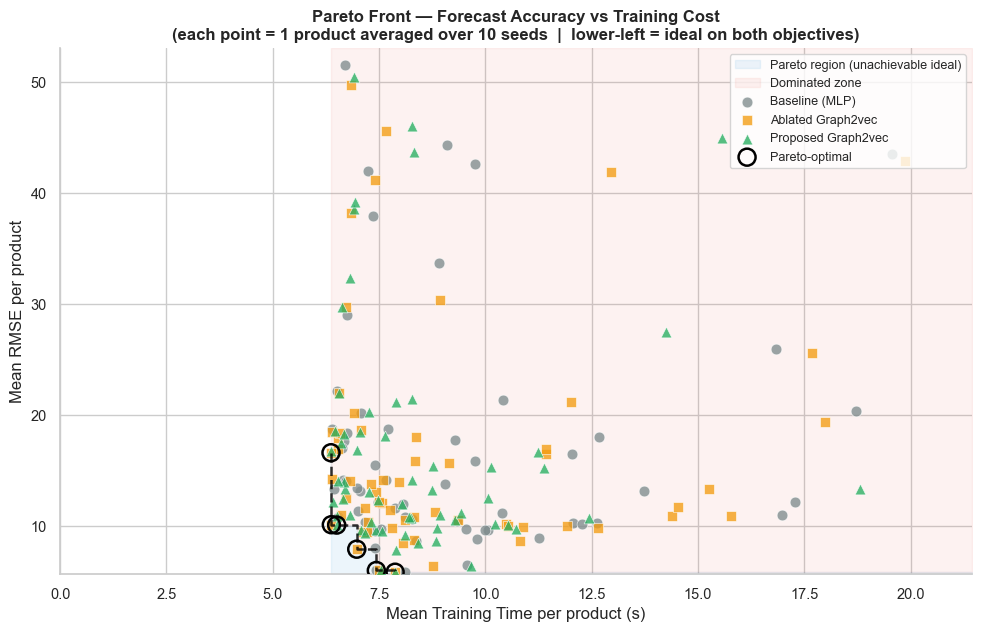

Saved → TimeDistributedMLP/fig_pareto_rmse_traintime.pdf

Pareto-optimal points by condition (total = 6):
condition
Ablated Graph2vec     4
Baseline (MLP)        1
Proposed Graph2vec    1


In [13]:
# ── Aggregate: one point per (product × condition) ───────────────────────────
specs = [
    (BASELINE, 'Baseline (MLP)',     '#7f8c8d', 'o'),
    (ABLATED,  'Ablated Graph2vec',  '#f39c12', 's'),
    (PROPOSED, 'Proposed Graph2vec', '#27ae60', '^'),
]

agg_rows = []
for cond_df, label, color, marker in specs:
    means = cond_df.groupby('item_id')[['rmse', 'train_time']].mean().reset_index()
    means['condition'] = label
    means['color']     = color
    means['marker']    = marker
    agg_rows.append(means)

all_pts = pd.concat(agg_rows, ignore_index=True)

# ── Pareto front (both objectives minimised: RMSE ↓, train_time ↓) ───────────
def pareto_mask(df, obj1, obj2):
    vals = df[[obj1, obj2]].values
    n = len(vals)
    dominated = np.zeros(n, dtype=bool)
    for i in range(n):
        for j in range(n):
            if i != j \
               and vals[j, 0] <= vals[i, 0] and vals[j, 1] <= vals[i, 1] \
               and (vals[j, 0] < vals[i, 0] or vals[j, 1] < vals[i, 1]):
                dominated[i] = True
                break
    return ~dominated

all_pts['pareto'] = pareto_mask(all_pts, 'rmse', 'train_time')
front = all_pts[all_pts['pareto']].sort_values('train_time').reset_index(drop=True)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6.5))
sns.set_theme(style='whitegrid', font_scale=1.05)

x_max = all_pts['train_time'].max() * 1.08
y_lo  = all_pts['rmse'].min()  * 0.97
y_hi  = all_pts['rmse'].max()  * 1.03

# Extend front to x_max so fill_between reaches the right edge
front_x = np.append(front['train_time'].values, x_max)
front_y = np.append(front['rmse'].values, front['rmse'].values[-1])

# Blue zone  = below the staircase = unachievable ideal (no solution is this good on both)
ax.fill_between(front_x, y_lo, front_y, step='post',
                color='#3498db', alpha=0.09, zorder=1,
                label='Pareto region (unachievable ideal)')

# Red zone   = above the staircase = dominated zone (suboptimal solutions)
ax.fill_between(front_x, front_y, y_hi, step='post',
                color='#e74c3c', alpha=0.07, zorder=1,
                label='Dominated zone')

# Staircase Pareto front
ax.step(front['train_time'], front['rmse'], where='post',
        color='black', linewidth=1.8, linestyle='--', alpha=0.8, zorder=4)

# Scatter all 183 points
for _, label, color, marker in specs:
    pts = all_pts[all_pts['condition'] == label]
    ax.scatter(pts['train_time'], pts['rmse'],
               label=label, color=color, marker=marker,
               s=60, alpha=0.78, edgecolors='white', linewidth=0.5, zorder=3)

# Ring the Pareto-optimal points
ax.scatter(front['train_time'], front['rmse'],
           s=150, facecolors='none', edgecolors='black',
           linewidths=1.8, zorder=5, label='Pareto-optimal')

ax.set_xlim(left=0, right=x_max)
ax.set_ylim(y_lo, y_hi)
ax.set_xlabel('Mean Training Time per product (s)', fontsize=12)
ax.set_ylabel('Mean RMSE per product', fontsize=12)
ax.set_title(
    'Pareto Front — Forecast Accuracy vs Training Cost\n'
    '(each point = 1 product averaged over 10 seeds  |  lower-left = ideal on both objectives)',
    fontsize=12, fontweight='bold',
)
ax.legend(frameon=True, fontsize=9, loc='upper right')
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig('TimeDistributedMLP/fig_pareto_rmse_traintime.pdf', bbox_inches='tight')
plt.show()

print("Saved → TimeDistributedMLP/fig_pareto_rmse_traintime.pdf")
print(f"\nPareto-optimal points by condition (total = {len(front)}):")
print(front.groupby('condition').size().rename('n_pareto_products').to_string())

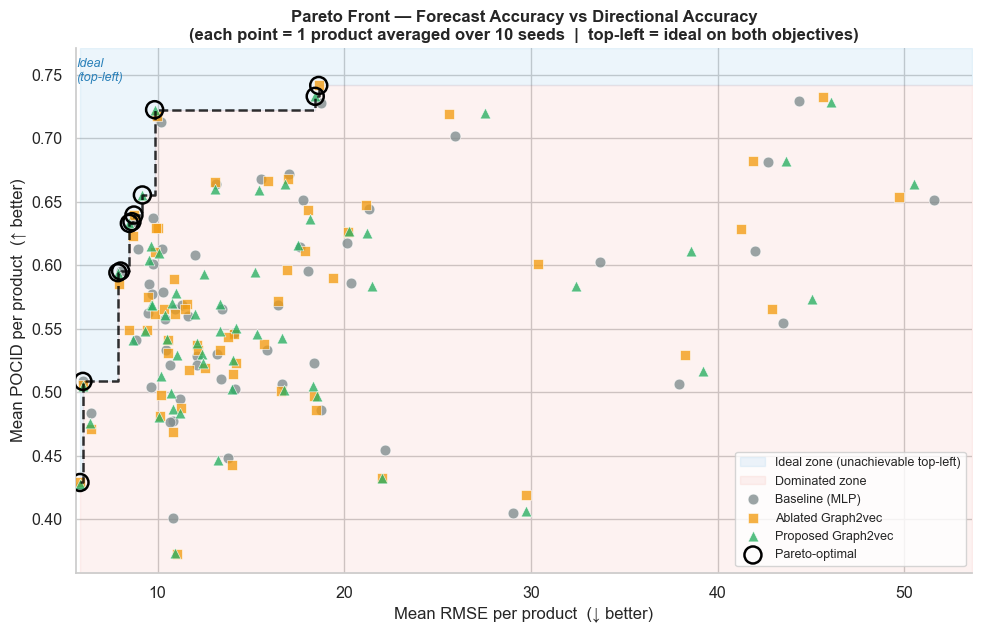

Saved → TimeDistributedMLP/fig_pareto_rmse_pocid.pdf

Pareto-optimal points by condition (total = 11):
condition
Ablated Graph2vec     3
Baseline (MLP)        3
Proposed Graph2vec    5


In [14]:
# ── Aggregate: one point per (product × condition) ───────────────────────────
specs = [
    (BASELINE, 'Baseline (MLP)',     '#7f8c8d', 'o'),
    (ABLATED,  'Ablated Graph2vec',  '#f39c12', 's'),
    (PROPOSED, 'Proposed Graph2vec', '#27ae60', '^'),
]

agg_rows = []
for cond_df, label, color, marker in specs:
    means = cond_df.groupby('item_id')[['rmse', 'pocid']].mean().reset_index()
    means['condition'] = label
    means['color']     = color
    means['marker']    = marker
    agg_rows.append(means)

all_pts = pd.concat(agg_rows, ignore_index=True)

# ── Pareto front: minimise RMSE ↓  AND  maximise POCID ↑ ─────────────────────
# Point i is dominated if ∃ j: rmse_j ≤ rmse_i  AND  pocid_j ≥ pocid_i  (≥1 strict)
def pareto_mask_min_max(df, min_col, max_col):
    vals = df[[min_col, max_col]].values
    n = len(vals)
    dominated = np.zeros(n, dtype=bool)
    for i in range(n):
        for j in range(n):
            if i != j \
               and vals[j, 0] <= vals[i, 0] and vals[j, 1] >= vals[i, 1] \
               and (vals[j, 0] < vals[i, 0] or vals[j, 1] > vals[i, 1]):
                dominated[i] = True
                break
    return ~dominated

all_pts['pareto'] = pareto_mask_min_max(all_pts, 'rmse', 'pocid')
# Sort by RMSE ascending — POCID increases along the front (you pay in accuracy to gain direction)
front = all_pts[all_pts['pareto']].sort_values('rmse').reset_index(drop=True)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6.5))
sns.set_theme(style='whitegrid', font_scale=1.05)

x_lo  = all_pts['rmse'].min()  * 0.96
x_max = all_pts['rmse'].max()  * 1.04
y_lo  = all_pts['pocid'].min() * 0.96
y_hi  = all_pts['pocid'].max() * 1.04

# Extend staircase to the right edge for fill_between
front_x = np.append(front['rmse'].values,  x_max)
front_y = np.append(front['pocid'].values, front['pocid'].values[-1])

# Blue = above staircase = ideal zone (low RMSE + high POCID) = unachievable top-left
ax.fill_between(front_x, front_y, y_hi, step='post',
                color='#3498db', alpha=0.09, zorder=1,
                label='Ideal zone (unachievable top-left)')

# Red = below staircase = dominated zone (high RMSE + low POCID)
ax.fill_between(front_x, y_lo, front_y, step='post',
                color='#e74c3c', alpha=0.07, zorder=1,
                label='Dominated zone')

# Staircase Pareto boundary
ax.step(front['rmse'], front['pocid'], where='post',
        color='black', linewidth=1.8, linestyle='--', alpha=0.8, zorder=4)

# Scatter all 183 points (61 products × 3 conditions)
for _, label, color, marker in specs:
    pts = all_pts[all_pts['condition'] == label]
    ax.scatter(pts['rmse'], pts['pocid'],
               label=label, color=color, marker=marker,
               s=60, alpha=0.78, edgecolors='white', linewidth=0.5, zorder=3)

# Ring the Pareto-optimal points
ax.scatter(front['rmse'], front['pocid'],
           s=150, facecolors='none', edgecolors='black',
           linewidths=1.8, zorder=5, label='Pareto-optimal')

# Annotate the ideal corner
ax.annotate('Ideal\n(top-left)', xy=(x_lo * 1.01, y_hi * 0.99),
            fontsize=9, color='#2980b9', fontstyle='italic',
            va='top', ha='left')

ax.set_xlim(x_lo, x_max)
ax.set_ylim(y_lo, y_hi)
ax.set_xlabel('Mean RMSE per product  (↓ better)', fontsize=12)
ax.set_ylabel('Mean POCID per product  (↑ better)', fontsize=12)
ax.set_title(
    'Pareto Front — Forecast Accuracy vs Directional Accuracy\n'
    '(each point = 1 product averaged over 10 seeds  |  top-left = ideal on both objectives)',
    fontsize=12, fontweight='bold',
)
ax.legend(frameon=True, fontsize=9, loc='lower right')
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig('TimeDistributedMLP/fig_pareto_rmse_pocid.pdf', bbox_inches='tight')
plt.show()

print("Saved → TimeDistributedMLP/fig_pareto_rmse_pocid.pdf")
print(f"\nPareto-optimal points by condition (total = {len(front)}):")
print(front.groupby('condition').size().rename('n_pareto_products').to_string())

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import friedmanchisquare

# 1. Carregar os dados
# df = pd.read_csv("seus_resultados.csv")

# 2. Agrupar pelas 10 seeds para ter o valor "médio" de cada modelo por produto
# Assumindo que 'ablate_z' define o seu modelo
df_mean = df.groupby(['item_id', 'ablate_z'])[['rmse', 'mae', 'pocid']].mean().reset_index()

# 3. Calcular os Ranks para cada produto
# Para RMSE e MAE, o menor valor é o melhor (ascending=True)
df_mean['rmse_rank'] = df_mean.groupby('item_id')['rmse'].rank(ascending=True)
df_mean['mae_rank'] = df_mean.groupby('item_id')['mae'].rank(ascending=True)

# Para POCID, o maior valor é o melhor (ascending=False)
df_mean['pocid_rank'] = df_mean.groupby('item_id')['pocid'].rank(ascending=False)

# 4. Calcular o Rank Médio Global (através de todos os 61 produtos)
global_ranks = df_mean.groupby('ablate_z')[['rmse_rank', 'mae_rank', 'pocid_rank']].mean()

print("=== RANK MÉDIO GLOBAL (Menor é melhor) ===")
print(global_ranks)
print("\n")

# 5. Teste Estatístico de Friedman (Exemplo usando RMSE)
# Pivotar a tabela para que cada modelo seja uma coluna e cada linha seja um produto
rmse_pivot = df_mean.pivot(index='item_id', columns='ablate_z', values='rmse')

# Extrair as arrays de cada modelo (certifique-se dos nomes exatos da sua coluna ablate_z)
# Nota: Adapte as strings abaixo se os seus dados tiverem 'baseline', 'True', 'False'
stat, p_value = friedmanchisquare(
    rmse_pivot['baseline'], 
    rmse_pivot['True'], 
    rmse_pivot['False']
)

print("=== TESTE DE FRIEDMAN (RMSE) ===")
print(f"Estatística: {stat:.3f}, p-value: {p_value:.5e}")
if p_value < 0.05:
    print("Conclusão: Existe uma diferença estatisticamente significativa entre os modelos!")
else:
    print("Conclusão: Não há diferença significativa entre os modelos.")

## Table 2 — Paired Wilcoxon Signed-Rank Tests

Pairs are formed by matching `(item_id, seed)` across conditions — this controls for product-level and seed-level variance.
Bonferroni-corrected threshold for 4 metrics × 2 comparisons = **α = 0.05 / 8 = 0.00625**.

In [6]:
key  = ['item_id', 'seed']
alpha_bonf = 0.05 / (len(METRICS) * 2)   # 8 tests total

# Build matched-pair dataframes
pairs_pb = PROPOSED[key + METRICS].merge(BASELINE[key + METRICS], on=key, suffixes=('_prop', '_base'))
pairs_pa = PROPOSED[key + METRICS].merge(ABLATED[key + METRICS],  on=key, suffixes=('_prop', '_abla'))

print(f"Matched pairs (Proposed–Baseline): {len(pairs_pb)} | "
      f"(Proposed–Ablated): {len(pairs_pa)}")
print(f"Bonferroni α = {alpha_bonf:.5f}\n")

rows = []
for m in METRICS:
    direction = BETTER[m]
    alt = 'less' if direction == 'lower' else 'greater'

    diff_pb = pairs_pb[f'{m}_prop'] - pairs_pb[f'{m}_base']
    diff_pa = pairs_pa[f'{m}_prop'] - pairs_pa[f'{m}_abla']

    stat_pb, p_pb = stats.wilcoxon(diff_pb, alternative=alt)
    stat_pa, p_pa = stats.wilcoxon(diff_pa, alternative=alt)

    def sig(p):
        if p < alpha_bonf: return '***'
        if p < 0.01:       return '**'
        if p < 0.05:       return '*'
        return 'n.s.'

    rows.append({
        'Metric':                     METRIC_LABELS[m],
        'Δ mean (Prop−Base)':         f"{diff_pb.mean():+.4f}",
        'p (Prop vs Base)':           f"{p_pb:.4f}",
        'Significance (vs Base)':     sig(p_pb),
        'Δ mean (Prop−Abla)':         f"{diff_pa.mean():+.4f}",
        'p (Prop vs Abla)':           f"{p_pa:.4f}",
        'Significance (vs Abla)':     sig(p_pa),
    })

stat_table = pd.DataFrame(rows).set_index('Metric')

display(stat_table.style
    .set_caption(
        "Table 2 — Wilcoxon Signed-Rank Tests (one-sided, paired by product × seed). "
        "Δ = Proposed − Competitor.  ***p < Bonferroni-α, **p < 0.01, *p < 0.05, n.s. = not significant."
    )
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size','13px'), ('font-weight','bold'), ('margin-bottom','8px')]},
        {'selector': 'th',      'props': [('text-align','center'), ('background-color','#2f527f')]},
    ])
    .applymap(lambda v: 'color: green; font-weight: bold' if v == '***' else
                        ('color: #27ae60' if v in ('**', '*') else
                         ('color: #c0392b' if v == 'n.s.' else '')),
              subset=['Significance (vs Base)', 'Significance (vs Abla)'])
)

Matched pairs (Proposed–Baseline): 609 | (Proposed–Ablated): 609
Bonferroni α = 0.00625



,Δ mean (Prop−Base),p (Prop vs Base),Significance (vs Base),Δ mean (Prop−Abla),p (Prop vs Abla),Significance (vs Abla)
Metric,,,,,,
RMSE ↓,-0.0298,0.1948,n.s.,+0.1016,0.5534,n.s.
MAE ↓,-0.0253,0.2512,n.s.,+0.1171,0.5015,n.s.
R² ↓,-0.0650,0.1319,n.s.,+0.0790,0.2183,n.s.
POCID ↑,-0.0017,0.7773,n.s.,-0.0007,0.7636,n.s.


## Step 1 — Shapiro-Wilk Normality Test on Per-Product Mean Differences

For each comparison and metric:
1. Compute the difference `Proposed − Competitor` for every `(item_id, seed)` pair.
2. Average those differences **per product** across the 10 seeds → **n = 61 observations** (one per product).
3. Run Shapiro-Wilk on those 61 values.

> **Why per-product means, not all 609 pairs?**
> Shapiro-Wilk on n=609 is massively overpowered — trivial, dissertation-irrelevant deviations will be flagged. Aggregating to product means gives a sensible sample size that matches the statistical unit you actually care about.
>
> **Decision rule:**  p > 0.05 → Normal → use paired t-test.  p ≤ 0.05 → Non-normal → use Wilcoxon signed-rank.

In [7]:
key = ['item_id', 'seed']

pairs_pb = PROPOSED[key + METRICS].merge(BASELINE[key + METRICS], on=key, suffixes=('_prop', '_base'))
pairs_pa = PROPOSED[key + METRICS].merge(ABLATED[key + METRICS],  on=key, suffixes=('_prop', '_abla'))

COMPARISONS = {
    'Proposed vs Baseline': (pairs_pb, '_base'),
    'Proposed vs Ablated':  (pairs_pa, '_abla'),
}

# normality_results[(comparison, metric)] = True  → differences are normal
normality_results = {}

# Also store the per-product diff vectors for Q-Q plots in the next cell
diff_vectors = {}

alpha_sw = 0.05

print(f"{'='*68}")
print(f"SHAPIRO-WILK NORMALITY TEST  (H₀: differences are normally distributed)")
print(f"Unit: per-product mean difference across 10 seeds  →  n = {pairs_pb['item_id'].nunique()} products")
print(f"α = {alpha_sw}")
print(f"{'='*68}")

rows_sw = []
for comp_name, (pairs_df, suffix) in COMPARISONS.items():
    print(f"\n  {'─'*30}  {comp_name}  {'─'*30}")
    for m in METRICS:
        # 1. seed-level differences
        diffs = pairs_df.assign(diff=pairs_df[f'{m}_prop'] - pairs_df[f'{m}{suffix}'])
        # 2. per-product mean
        per_prod = diffs.groupby('item_id')['diff'].mean()

        stat, p = stats.shapiro(per_prod)
        is_normal = p > alpha_sw
        verdict = "NORMAL      → paired t-test" if is_normal else "NOT NORMAL  → Wilcoxon"
        flag    = "✓" if is_normal else "✗"

        normality_results[(comp_name, m)] = is_normal
        diff_vectors[(comp_name, m)]      = per_prod.values

        lbl = METRIC_LABELS[m]
        print(f"    {lbl:<12}  W = {stat:.4f}   p = {p:.4f}   {flag}  {verdict}")
        rows_sw.append({
            'Comparison': comp_name,
            'Metric':     lbl,
            'W':          round(stat, 4),
            'p-value':    round(p, 4),
            'Normal?':    '✓ Yes' if is_normal else '✗ No',
            'Recommended test': 'Paired t-test' if is_normal else 'Wilcoxon signed-rank',
        })

print(f"\n{'='*68}")

sw_table = pd.DataFrame(rows_sw)
display(sw_table.style
    .hide(axis='index')
    .set_caption("Shapiro-Wilk results — per-product mean differences (n = 61)")
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size','13px'), ('font-weight','bold')]},
        {'selector': 'th',      'props': [('text-align','center'), ('background-color','#2f527f'), ('color','white')]},
    ])
    .applymap(lambda v: 'color: #27ae60; font-weight:bold' if v == '✓ Yes'
              else ('color: #c0392b; font-weight:bold' if v == '✗ No' else ''),
              subset=['Normal?'])
)

SHAPIRO-WILK NORMALITY TEST  (H₀: differences are normally distributed)
Unit: per-product mean difference across 10 seeds  →  n = 61 products
α = 0.05

  ──────────────────────────────  Proposed vs Baseline  ──────────────────────────────
    RMSE ↓        W = 0.8330   p = 0.0000   ✗  NOT NORMAL  → Wilcoxon
    MAE ↓         W = 0.8222   p = 0.0000   ✗  NOT NORMAL  → Wilcoxon
    R² ↓          W = 0.8904   p = 0.0001   ✗  NOT NORMAL  → Wilcoxon
    POCID ↑       W = 0.9010   p = 0.0001   ✗  NOT NORMAL  → Wilcoxon

  ──────────────────────────────  Proposed vs Ablated  ──────────────────────────────
    RMSE ↓        W = 0.8219   p = 0.0000   ✗  NOT NORMAL  → Wilcoxon
    MAE ↓         W = 0.7660   p = 0.0000   ✗  NOT NORMAL  → Wilcoxon
    R² ↓          W = 0.8412   p = 0.0000   ✗  NOT NORMAL  → Wilcoxon
    POCID ↑       W = 0.9804   p = 0.4364   ✓  NORMAL      → paired t-test



Comparison,Metric,W,p-value,Normal?,Recommended test
Proposed vs Baseline,RMSE ↓,0.833000,0.000000,✗ No,Wilcoxon signed-rank
Proposed vs Baseline,MAE ↓,0.822200,0.000000,✗ No,Wilcoxon signed-rank
Proposed vs Baseline,R² ↓,0.890400,0.000100,✗ No,Wilcoxon signed-rank
Proposed vs Baseline,POCID ↑,0.901000,0.000100,✗ No,Wilcoxon signed-rank
Proposed vs Ablated,RMSE ↓,0.821900,0.000000,✗ No,Wilcoxon signed-rank
Proposed vs Ablated,MAE ↓,0.766000,0.000000,✗ No,Wilcoxon signed-rank
Proposed vs Ablated,R² ↓,0.841200,0.000000,✗ No,Wilcoxon signed-rank
Proposed vs Ablated,POCID ↑,0.980400,0.436400,✓ Yes,Paired t-test


### Q-Q Plots — Visual Normality Check

Points hugging the diagonal = normal. Heavy tails or systematic curves = non-normal.

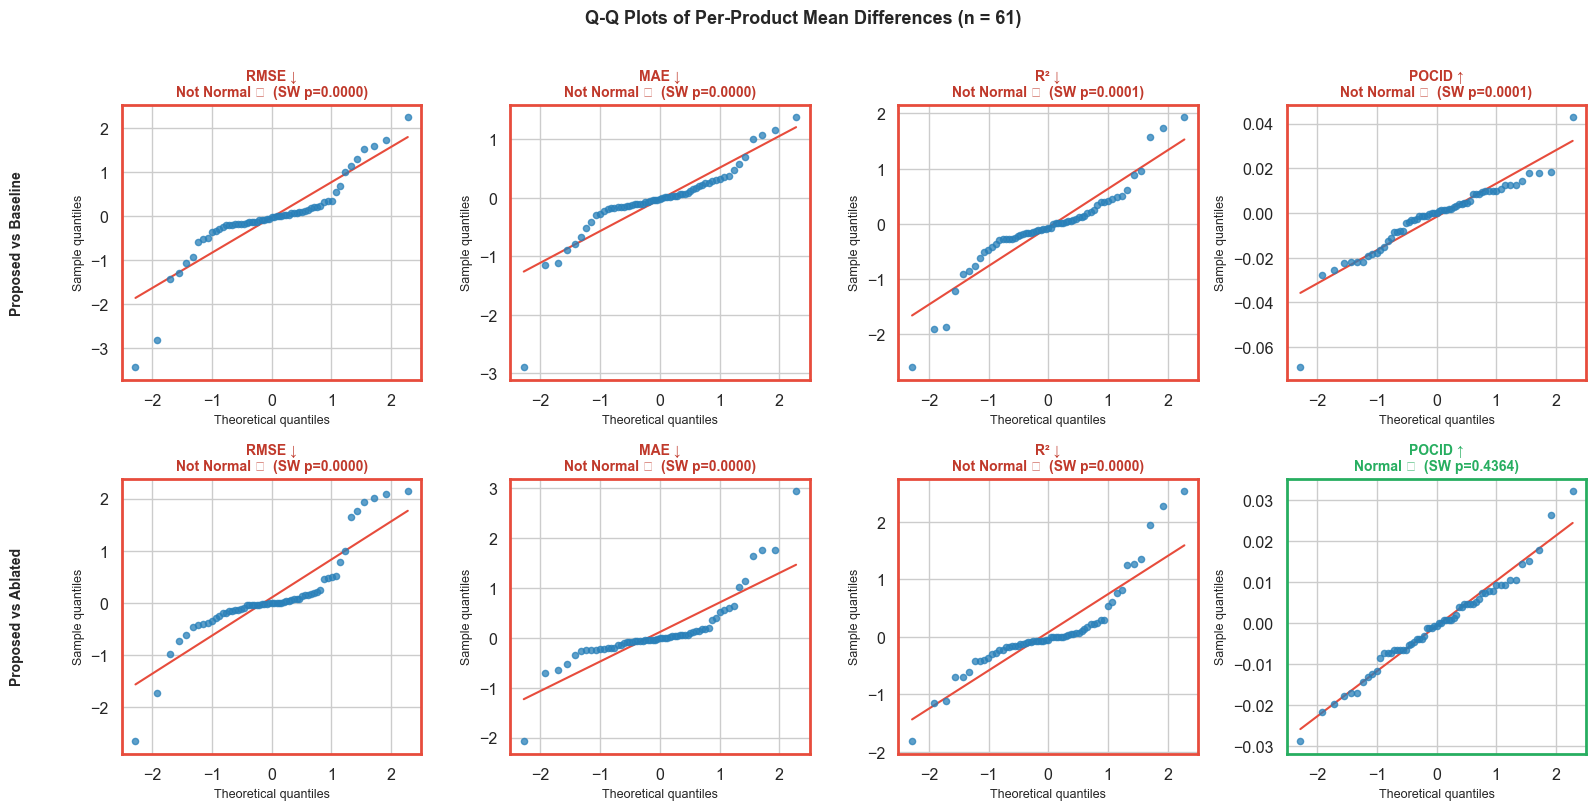

Saved → TimeDistributedMLP/shapiro_qq_plots.pdf


In [8]:
n_comp = len(COMPARISONS)   # 2
n_met  = len(METRICS)       # 4

fig, axes = plt.subplots(n_comp, n_met, figsize=(n_met * 4, n_comp * 4))
sns.set_theme(style='whitegrid', font_scale=0.95)

for row_idx, comp_name in enumerate(COMPARISONS):
    for col_idx, m in enumerate(METRICS):
        ax = axes[row_idx, col_idx]
        data = diff_vectors[(comp_name, m)]

        # Q-Q plot
        (osm, osr), (slope, intercept, _) = stats.probplot(data, dist='norm')
        ax.scatter(osm, osr, color='#2980b9', s=20, alpha=0.75, zorder=3)
        ax.plot(osm, slope * np.array(osm) + intercept,
                color='#e74c3c', linewidth=1.5, zorder=2)

        is_normal = normality_results[(comp_name, m)]
        border_color = '#27ae60' if is_normal else '#e74c3c'
        for spine in ax.spines.values():
            spine.set_edgecolor(border_color)
            spine.set_linewidth(2)

        sw_p = [r['p-value'] for r in rows_sw
                if r['Comparison'] == comp_name and r['Metric'] == METRIC_LABELS[m]][0]
        verdict = "Normal ✓" if is_normal else "Not Normal ✗"
        ax.set_title(f"{METRIC_LABELS[m]}\n{verdict}  (SW p={sw_p:.4f})",
                     fontsize=10, fontweight='bold',
                     color='#27ae60' if is_normal else '#c0392b')
        ax.set_xlabel('Theoretical quantiles', fontsize=9)
        ax.set_ylabel('Sample quantiles', fontsize=9)

    # Row label
    axes[row_idx, 0].annotate(
        comp_name, xy=(0, 0.5), xytext=(-0.35, 0.5),
        xycoords='axes fraction', textcoords='axes fraction',
        fontsize=10, fontweight='bold', rotation=90, va='center', ha='center',
    )

fig.suptitle('Q-Q Plots of Per-Product Mean Differences (n = 61)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('TimeDistributedMLP/shapiro_qq_plots.pdf', bbox_inches='tight')
plt.show()
print("Saved → TimeDistributedMLP/shapiro_qq_plots.pdf")